# M2K Keltner channel breakout, long-only, 15-minute bars (Tradovate exchange)

Same strategy (`DonchianBreakoutStrategy` fed `Indicators.keltner_channels`'
bands instead of `Indicators.donchian_channels`', per
`keltner_channel_breakout_long_mes_15m.ipynb`'s reuse rationale) applied to
**M2K** instead of MES.

**Why this pass exists**: Keltner channel breakout was the third structurally
different mechanism (after Donchian channel breakout, SuperTrend ATR-flip) to
confirm the same long-only/15-minute edge on MES, with the strongest MES
TRAIN Sharpe lower bound yet (+0.029). Both prior mechanisms transferred to
M2K at least as well as MES (MNQ notably *better* on both;
M2K notably weaker on both) -- this pass checks whether Keltner breakout shows
the same per-symbol pattern. `direction=long`, `risk_reward_ratio=2.0`,
`atr_length=10` fixed, same `length`/`atr_mult` grid as the MES pass for
direct comparability.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import DonchianBreakoutStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "M2K"
SYMBOL = "M2K/USD"
INTERVAL = 15
UNIT_OF_TIME = "minute"

data_path = _find_upwards("apps/backtester/datasets/databento/M2K_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(data_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 167703  span: 2019-05-05 22:14:59.999000 -> 2026-07-13 07:14:59.999000


## Grid search: EMA length x ATR multiplier, direction=long

`risk_reward_ratio=2.0`, `atr_length=10` held fixed.


In [3]:
LENGTH_CANDIDATES = [10, 20, 30, 50, 75]
ATR_MULT_CANDIDATES = [1.5, 2.0, 2.5, 3.0]
ATR_LENGTH = 10
RISK_REWARD_RATIO = 2.0
DEPOSIT_USD = 50_000


def run_keltner_breakout_backtest(ohlc_slice: pd.DataFrame, length: int, atr_mult: float, key: str,
                                   direction: StrategyDirection = StrategyDirection.long):
    lower, _middle, upper = Indicators.keltner_channels(ohlc_slice, length=length, atr_length=ATR_LENGTH, atr_mult=atr_mult)

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="keltner_upper", df=upper)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="keltner_lower", df=lower)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=DonchianBreakoutStrategy(
            key=key, market=market, symbol=SYMBOL, upper_key="keltner_upper", lower_key="keltner_lower",
            risk_reward_ratio=RISK_REWARD_RATIO, direction=direction,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


grid_rows = []
grid_backtests = {}
_t0 = time.time()
for length in LENGTH_CANDIDATES:
    for atr_mult in ATR_MULT_CANDIDATES:
        bt, drawdown_mw = run_keltner_breakout_backtest(ohlc, length, atr_mult, key=f"KC_long_{length}_{atr_mult}")
        summary = bt.reporter.summary["algo"]
        total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
        grid_backtests[(length, atr_mult)] = (bt, drawdown_mw)
        grid_rows.append({
            "length": length, "atr_mult": atr_mult,
            "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
            "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
            "trades_per_year": round(summary["closed_trades"] / 7.2, 1), "win_rate_percent": summary["win_rate_percent"],
            "profit_factor": summary["profit_factor"], "r_multiple_expectancy": summary["r_multiple_expectancy"],
            "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
            "total_fees_usd": total_fees, "account_failed": drawdown_mw.account_failed,
        })
    print(f"length={length} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid_results = pd.DataFrame(grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print(f"\ngrid done in {time.time() - _t0:.0f}s\n")
print(grid_results.to_string())


length=10 done, 27s elapsed


length=20 done, 60s elapsed


length=30 done, 100s elapsed


length=50 done, 149s elapsed


length=75 done, 189s elapsed



grid done in 189s

    length  atr_mult  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0       20       3.0           54.291387      0.371522              -23.4439          293.0             40.7         32.081911       1.232548              -0.037543              1.175986         103.819332         3329.69           False
1       75       3.0           22.235109      0.200494              -39.0456          351.0             48.8         31.908832       1.113372              -0.042735              1.077065          39.095426         2942.94           False
2       50       3.0           18.194063      0.179824              -43.8014          390.0             54.2         31.538462       1.117712              -0.053846              1.062203          32.721952         3579.03           False
3       75       2.5        

### Heatmaps: Sharpe ratio and net return across (length, atr_mult)


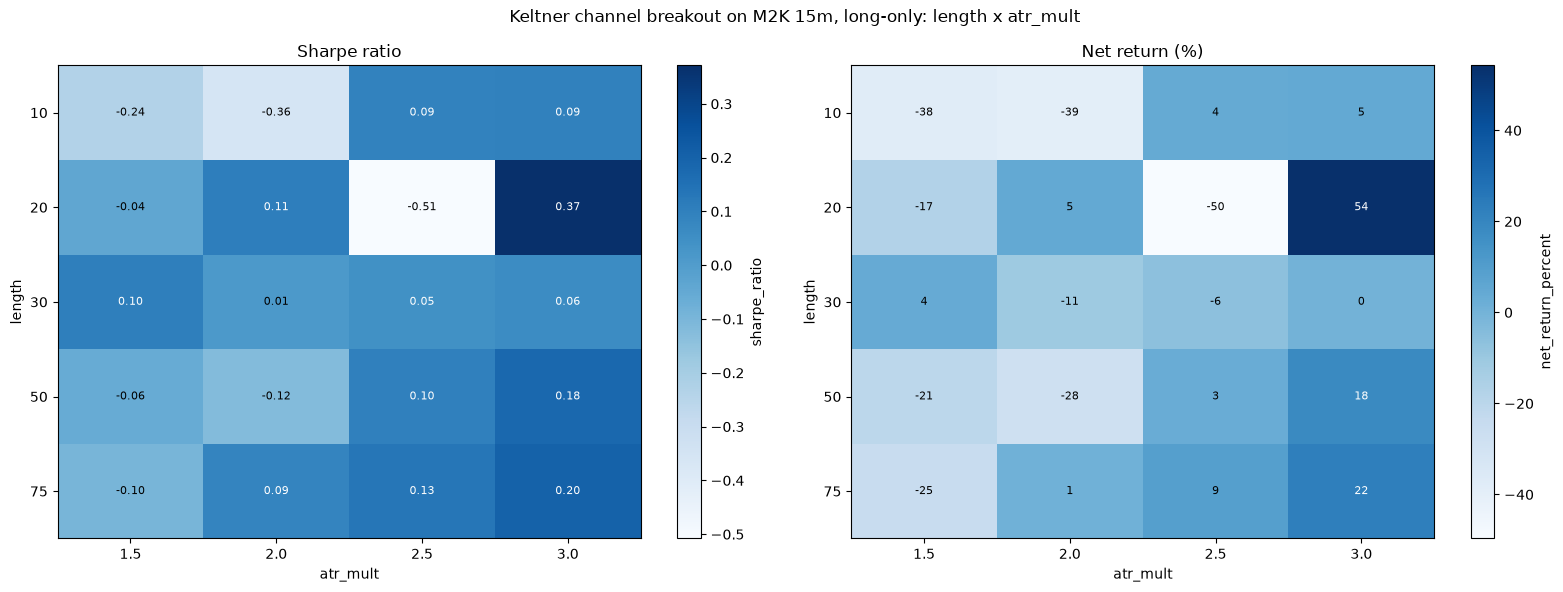

In [4]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel("atr_mult")
    ax.set_ylabel("length")
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid_results.pivot(index="length", columns="atr_mult", values="sharpe_ratio")
return_pivot = grid_results.pivot(index="length", columns="atr_mult", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle(f"Keltner channel breakout on {DISPLAY_SYMBOL} 15m, long-only: length x atr_mult")
fig.tight_layout()
plt.show()


## Detailed report for the best combo

Full HTML summary (year-by-year split) and equity/drawdown charts for the
grid's best combo -- same report format as every other notebook in this
pipeline.


Best combo: length=20, atr_mult=3.0
Candles Processed: 167702
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,M2K/USD,description
sharpe_ratio,0.3715,0.2904,1.2295,-0.1189,-0.3359,0.3645,0.3236,0.7085,-0.1051,0.3891,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,0.5542,0.4371,1.9558,-0.1691,-0.4736,0.5562,0.4908,1.0270,-0.1533,0.5585,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,13.7349,8.7876,19.6704,11.3501,14.8661,10.4696,12.3594,14.2332,14.0258,21.7514,How much the equity curve swings per year. Lower = smoother.
cagr_percent,6.2132,3.1893,38.1585,-2.8525,-8.4738,4.8656,4.8175,14.0826,-3.5039,9.2282,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,0.2650,0.3795,4.3461,-0.3238,-0.5719,0.4333,0.4564,0.9785,-0.1938,0.2116,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,2.3158,0.2482,4.3461,-0.3229,-0.5704,0.4321,0.4564,0.9756,-0.1033,2.0342,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-23.4439,-8.4048,-8.7799,-8.8108,-14.8163,-11.2293,-10.5556,-14.3922,-18.0830,-43.6096,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,1227,216,93,187,167,165,91,138,180,1097,How long it took to recover the loss. Shorter is better.
ulcer_index,10.0550,3.9766,3.8361,4.9852,6.5561,5.9839,3.6318,5.0106,7.8061,15.6277,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-1.3335,-0.8709,-1.8332,-1.2831,-1.6073,-1.1096,-1.2592,-1.1319,-1.5480,-1.9930,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


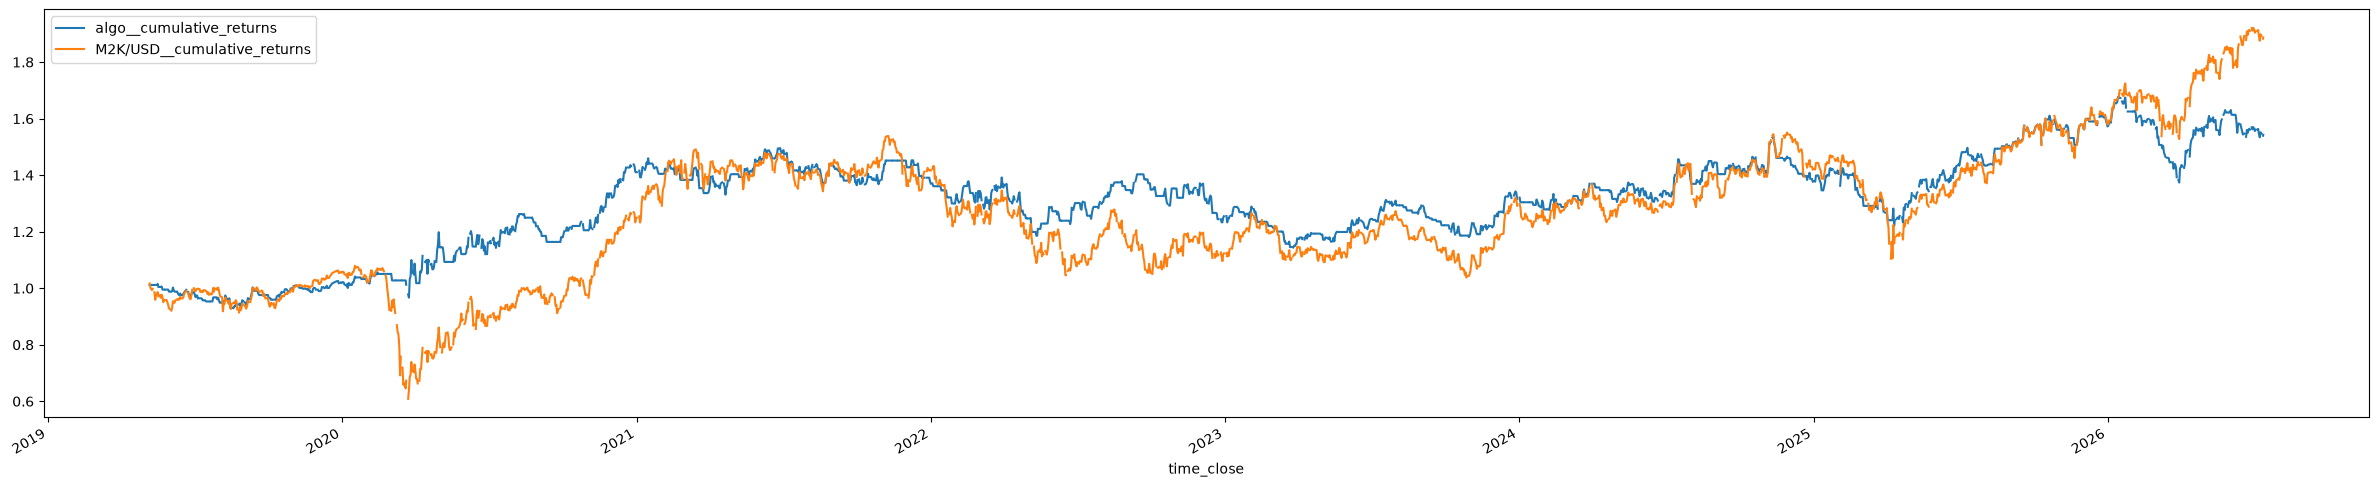

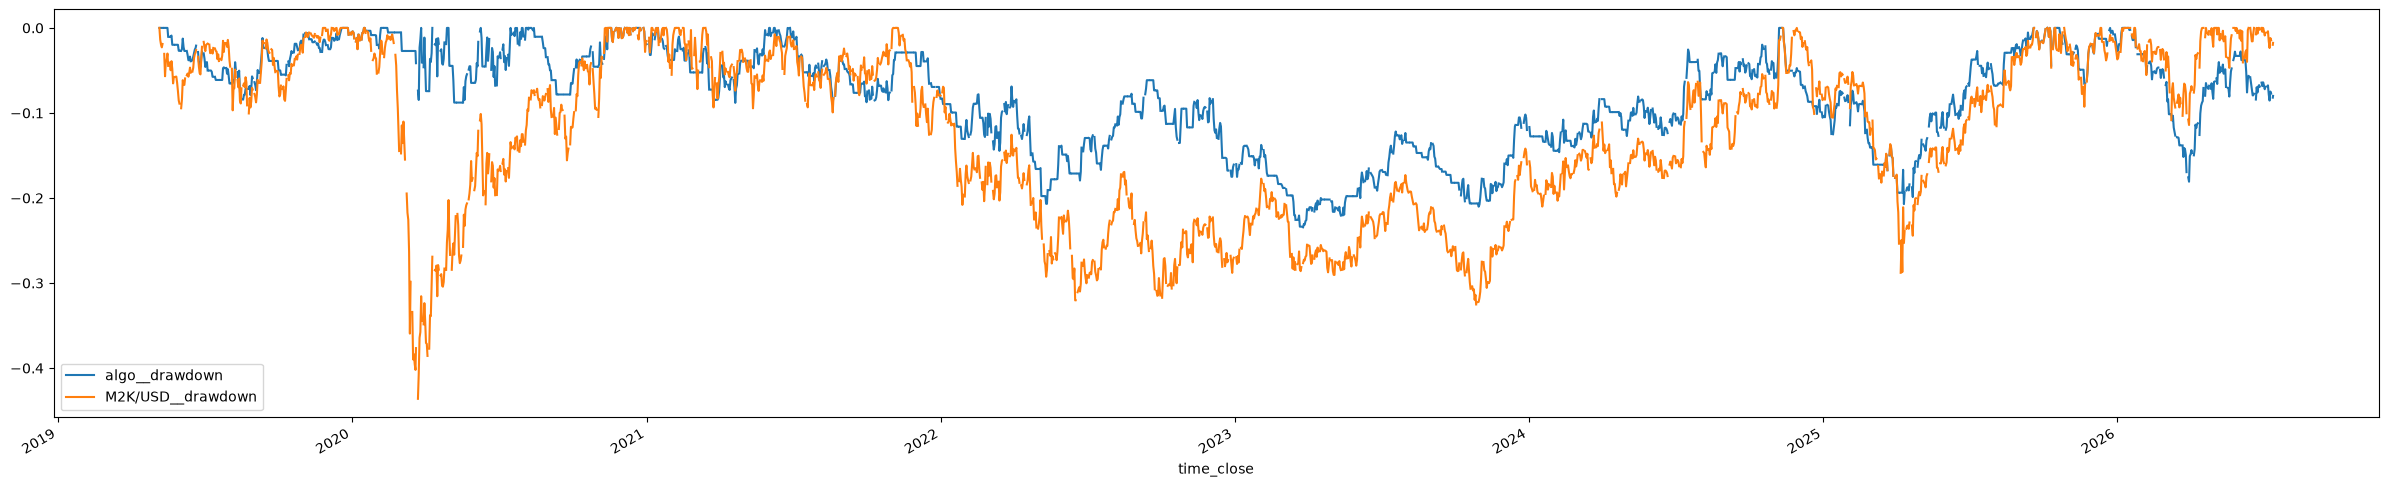

In [5]:
best_length, best_atr_mult = grid_results.iloc[0][["length", "atr_mult"]]
best_length = int(best_length)
print(f"Best combo: length={best_length}, atr_mult={best_atr_mult}")
best_backtest, best_drawdown_mw = grid_backtests[(best_length, best_atr_mult)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Holdout check: does the best combo survive a train/test split?


In [6]:
split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


holdout_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_keltner_breakout_backtest(ohlc_slice, best_length, float(best_atr_mult), key=f"KC_holdout_{label}")
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(holdout_df.to_string())


train/test split at 2024-09-25 15:59:59.999000  (125777 train bars, 41926 test bars)


                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                        293         32.081911      0.072139        -0.024088        0.371522           54.291387              1.175986         103.819332              -23.4439           False
TRAIN (75%)                 252         33.333333      0.076738        -0.027039        0.398033           42.203518              1.183123          97.418020              -23.4439           False
TEST (last 25%, unseen)      51         23.529412      0.044472        -0.185988        0.170327            3.678964              1.078091          43.496703              -20.6033           False


## Findings

**Weaker than MES/MNQ, consistent with M2K's Donchian and SuperTrend results
-- though this is M2K's best full-history Sharpe of the three mechanisms.**
Best combo (`length=20, atr_mult=3.0`): FULL Sharpe 0.37 (higher than M2K's
Donchian or SuperTrend best), `dollar_profit_factor` 1.18.

Holdout still doesn't clear the bar: TRAIN `trade_sharpe_lb`=-0.027, TEST
`trade_sharpe_lb`=-0.186 (51 trades, small and noisy, but still clearly
negative point estimate territory). Third mechanism, third time M2K's holdout
lower bound stays negative on both halves.

**Cross-mechanism, cross-symbol summary (9 combinations tested across this
whole notebook family)**: MNQ > MES > M2K, consistently, across Donchian
channel breakout, SuperTrend ATR-flip, and Keltner EMA+ATR breakout alike.
This is now a well-replicated pattern, not a fluke of any one signal -- M2K
(Russell 2000 futures) does not appear to carry this repo's long-only
trend-following edge the way the two larger-cap indices do, plausibly because
small caps chopped and underperformed relative to the S&P and (especially)
Nasdaq-100 over 2019-2026.
